In [21]:
import numpy as np, pandas as pd, os, time, random, zipfile, urllib.request

URL = ("https://raw.githubusercontent.com/WebClub-NITK/Intelligence-SIG-Recs-2026/main/"
       "mandatory-tasks/recommender-systems-cf-to-dlrm/datasets/dataset%20(tasks%202%20and%203).zip")
os.makedirs("/kaggle/working/data", exist_ok=True)
urllib.request.urlretrieve(URL, "/kaggle/working/data/ctr.zip")
zipfile.ZipFile("/kaggle/working/data/ctr.zip").extractall("/kaggle/working/data")

train_full = pd.read_csv("/kaggle/working/data/train.csv")
test = pd.read_csv("/kaggle/working/data/test.csv")
NUM = [f"integer_feature_{i}" for i in range(1, 14)]
CAT = [f"categorical_feature_{i}" for i in range(1, 27)]

print("rows:", train_full.shape, test.shape)
print("click rate train / test:", round(train_full.label.mean(), 4), round(test.label.mean(), 4),
      "| clicks:", int(train_full.label.sum()), int(test.label.sum()))
miss = train_full[NUM + CAT].isna().mean().sort_values(ascending=False)
print("most-missing columns:", miss.head(5).round(3).to_dict())
card = train_full[CAT].nunique().sort_values()
print("cardinality min / median / max:", card.min(), int(card.median()), card.max(), "| columns above 1000 levels:", int((card > 1000).sum()))
unseen = pd.Series({c: (~test[c].dropna().isin(set(train_full[c].dropna()))).mean() for c in CAT})
print("test categories unseen in train: mean", round(unseen.mean(), 3), "max", round(unseen.max(), 3))
print("integer skewness (top 3):", train_full[NUM].skew().sort_values(ascending=False).head(3).round(1).to_dict())
print("negative values:", {c: int((train_full[c] < 0).sum()) for c in NUM if (train_full[c] < 0).any()})

rows: (40000, 40) (10000, 40)
click rate train / test: 0.032 0.0335 | clicks: 1280 335
most-missing columns: {'integer_feature_4': 0.4, 'integer_feature_5': 0.385, 'integer_feature_11': 0.385, 'categorical_feature_14': 0.364, 'categorical_feature_16': 0.364}
cardinality min / median / max: 3 2568 13508 | columns above 1000 levels: 15
test categories unseen in train: mean 0.092 max 0.362
integer skewness (top 3): {'integer_feature_1': 108.2, 'integer_feature_7': 32.4, 'integer_feature_4': 25.5}
negative values: {'integer_feature_8': 2455}


In [22]:
train_full.head()

,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,49.0,520.0,0.0,353.0,5.0,0.0,0.0,0,2,...,1f7fc70b,628f1b8d,9512c20b,c5362157,a9ad4e8e,2b6a4b2f,bc71cd9d,9f4102b0,ff654802,2f33557c
1,0,NaN,408.0,NaN,NaN,NaN,0.0,0.0,-1,1,...,NaN,a1eb1511,0a1d513f,7fdb0729,747f6ecc,62682372,NaN,401a16fe,30436bfc,b757e957
2,0,28.0,37.0,2.0,5.0,4.0,5.0,1.0,974,14,...,753da5f3,d9f758ff,9512c20b,682d90ba,09afda28,307a0f03,f942364c,16e6b497,57e36578,a7ab145d
3,0,1.0,603.0,1.0,NaN,1.0,0.0,0.0,13,1,...,NaN,b8170bba,108a0699,47849e55,73b3f46d,d994ba60,NaN,328e967b,ff654802,2ba8d787
4,0,NaN,525.0,3.0,8.0,126.0,1.0,0.0,10,11,...,753da5f3,b8170bba,55191c09,0e29b5da,0683bc6f,47b99d80,d2b125b2,00a688ec,30436bfc,b757e957


In [23]:
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED)
tr, va = train_test_split(train_full, test_size=0.2, stratify=train_full.label, random_state=SEED)
tr, va = tr.reset_index(drop=True), va.reset_index(drop=True)
print("train / val / test rows:", len(tr), len(va), len(test),
      "| clicks:", int(tr.label.sum()), int(va.label.sum()), int(test.label.sum()))

med = tr[NUM].median()
def prep_num(d): return np.log1p(d[NUM].fillna(med).clip(lower=0))
_x = prep_num(tr); mu, sd = _x.mean(), _x.std().replace(0, 1)
Xn = {k: ((prep_num(d) - mu) / sd).to_numpy(np.float32) for k, d in [("tr", tr), ("va", va), ("te", test)]}

MIN_COUNT = 5
vocab = {}
for c in CAT:
    vc = tr[c].value_counts()
    vocab[c] = {v: i + 2 for i, v in enumerate(vc[vc >= MIN_COUNT].index)}
rare = {c: set(tr[c].dropna().unique()) - set(vocab[c]) for c in CAT}
def prep_cat(d):
    out = np.zeros((len(d), len(CAT)), dtype=np.int64)
    for j, c in enumerate(CAT):
        col = d[c]; idx = col.map(vocab[c])
        out[:, j] = np.where(idx.notna(), idx.fillna(0), np.where(col.isin(rare[c]), 1, 0))
    return out
Xc = {k: prep_cat(d) for k, d in [("tr", tr), ("va", va), ("te", test)]}
y = {"tr": tr.label.to_numpy(np.float32), "va": va.label.to_numpy(np.float32), "te": test.label.to_numpy(np.float32)}
sizes = [len(vocab[c]) + 2 for c in CAT]

print("dense train mean / std (expect ~0 / ~1):", round(float(Xn["tr"].mean()), 3), round(float(Xn["tr"].std()), 3))
print("embedding table sizes min / median / max:", min(sizes), int(np.median(sizes)), max(sizes), "| total rows:", sum(sizes))
print("categorical cells mapped to unknown (0) / rare (1): val", round(float((Xc['va'] == 0).mean()), 3), round(float((Xc['va'] == 1).mean()), 3),
      "| test", round(float((Xc['te'] == 0).mean()), 3), round(float((Xc['te'] == 1).mean()), 3))

train / val / test rows: 32000 8000 10000 | clicks: 1024 256 335
dense train mean / std (expect ~0 / ~1): -0.0 1.0
embedding table sizes min / median / max: 4 339 1291 | total rows: 9912
categorical cells mapped to unknown (0) / rare (1): val 0.141 0.06 | test 0.157 0.06


device: cpu
epoch 1 | train loss 0.1755 | val loss 0.1302 | val AUC 0.7363 | val PR-AUC 0.1038
epoch 2 | train loss 0.1346 | val loss 0.1300 | val AUC 0.7366 | val PR-AUC 0.1049
epoch 3 | train loss 0.1308 | val loss 0.1309 | val AUC 0.7376 | val PR-AUC 0.0988
epoch 4 | train loss 0.1272 | val loss 0.1309 | val AUC 0.7235 | val PR-AUC 0.0916
epoch 5 | train loss 0.1247 | val loss 0.1324 | val AUC 0.7097 | val PR-AUC 0.0896
baseline: best epoch 2 | params 169153 | val F1 threshold 0.07
{'roc_auc': 0.7366, 'pr_auc': 0.1049, 'logloss': 0.13, 'acc': 0.926, 'f1': 0.1778, 'precision': 0.1379, 'recall': 0.25}
references: majority-class accuracy 0.968 | random-ranker PR-AUC about 0.032


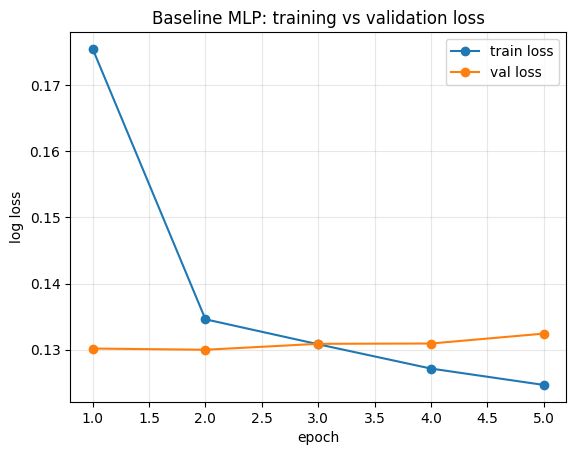

In [24]:
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss, accuracy_score,
                             f1_score, precision_score, recall_score)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
torch.manual_seed(SEED)

def clipp(p): return np.clip(p, 1e-7, 1 - 1e-7)
def metrics(yt, p, thr):
    pred = (p >= thr).astype(int)
    return dict(roc_auc=roc_auc_score(yt, p), pr_auc=average_precision_score(yt, p), logloss=log_loss(yt, clipp(p)),
                acc=accuracy_score(yt, pred), f1=f1_score(yt, pred, zero_division=0),
                precision=precision_score(yt, pred, zero_division=0), recall=recall_score(yt, pred, zero_division=0))
def best_f1_threshold(yt, p):
    ts = np.linspace(0.01, 0.5, 99)
    return float(ts[int(np.argmax([f1_score(yt, (p >= t).astype(int), zero_division=0) for t in ts]))])

class MLP(nn.Module):
    def __init__(self, sizes, n_dense, emb_dim=8, hidden=(256, 128), dropout=0.2):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(s, emb_dim) for s in sizes])
        d = n_dense + emb_dim * len(sizes)
        layers = []
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]; d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, xd, xc):
        e = [emb(xc[:, j]) for j, emb in enumerate(self.embs)]
        return self.net(torch.cat([xd] + e, dim=1)).squeeze(1)

T = {k: (torch.tensor(Xn[k]), torch.tensor(Xc[k]), torch.tensor(y[k])) for k in ["tr", "va"]}   # test is not loaded

def predict_proba(m, xd, xc, bs=4096):
    m.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(xd), bs):
            out.append(torch.sigmoid(m(xd[i:i + bs].to(device), xc[i:i + bs].to(device))).cpu().numpy())
    return np.concatenate(out)

def run(cfg, epochs=15, bs=512, lr=1e-3, wd=1e-5, patience=3):
    torch.manual_seed(SEED)
    m = MLP(sizes, len(NUM), **cfg).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss()
    xd, xc, yt = [t.to(device) for t in T["tr"]]
    hist, best, bad = [], {"pr": -1.0, "state": None, "ep": 0}, 0
    for ep in range(1, epochs + 1):
        m.train(); perm = torch.randperm(len(yt), device=device); tot = 0.0
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            opt.zero_grad(set_to_none=True)
            loss = lossf(m(xd[idx], xc[idx]), yt[idx])
            loss.backward(); opt.step(); tot += loss.item() * len(idx)
        p = predict_proba(m, *T["va"][:2])
        row = (ep, tot / len(yt), log_loss(y["va"], clipp(p)), roc_auc_score(y["va"], p), average_precision_score(y["va"], p))
        hist.append(row); print("epoch %d | train loss %.4f | val loss %.4f | val AUC %.4f | val PR-AUC %.4f" % row)
        if row[4] > best["pr"]:
            best = {"pr": row[4], "ep": ep, "state": {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}}; bad = 0
        else:
            bad += 1
            if bad >= patience: break
    m.load_state_dict(best["state"])
    return m, hist, best

cfg0 = dict(emb_dim=8, hidden=(256, 128), dropout=0.2)
m0, hist0, best0 = run(cfg0)
p_va = predict_proba(m0, *T["va"][:2])
thr0 = best_f1_threshold(y["va"], p_va)
print("baseline: best epoch", best0["ep"], "| params", sum(p.numel() for p in m0.parameters()), "| val F1 threshold", round(thr0, 3))
print({k: round(float(v), 4) for k, v in metrics(y["va"], p_va, thr0).items()})
print("references: majority-class accuracy", round(1 - y["va"].mean(), 4), "| random-ranker PR-AUC about", round(float(y["va"].mean()), 4))

h = np.array(hist0)
plt.plot(h[:, 0], h[:, 1], marker="o", label="train loss"); plt.plot(h[:, 0], h[:, 2], marker="o", label="val loss")
plt.xlabel("epoch"); plt.ylabel("log loss"); plt.legend(); plt.grid(alpha=0.3); plt.title("Baseline MLP: training vs validation loss")
os.makedirs("/kaggle/working/results", exist_ok=True)
plt.savefig("/kaggle/working/results/baseline_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## Baseline: vanilla MLP

Each categorical column has an 8-d embedding; these are concatenated with the
13 standardised dense features and passed through two hidden layers (256, 128)
with ReLU and dropout 0.2 to one logit, trained with binary cross-entropy and
Adam (lr 1e-3, batch 512). The epoch is chosen by validation PR-AUC with
early stopping (patience 3), and the threshold by validation F1.

| Epoch | Train loss | Val loss | Val AUC | Val PR-AUC |
|---|---|---|---|---|
| 1 | 0.1755 | 0.1302 | 0.7363 | 0.1038 |
| 2 | 0.1346 | 0.1300 | 0.7366 | 0.1049 |
| 3 | 0.1308 | 0.1309 | 0.7376 | 0.0988 |
| 4 | 0.1272 | 0.1309 | 0.7235 | 0.0916 |
| 5 | 0.1247 | 0.1324 | 0.7097 | 0.0896 |

Best epoch 2 (169,153 parameters): ROC-AUC 0.7366, PR-AUC 0.1049 (a random
ranker gets about 0.032), log loss 0.1300 (always predicting the click rate
gives about 0.1416), F1 0.1778 at threshold 0.07 (precision 0.1379, recall
0.25). The model overfits quickly: train loss keeps falling while validation
loss rises after epoch 2. Accuracy (0.926) is below the 0.968 of a model that
never predicts a click, because the F1-optimal threshold flags about 6% of
impressions; accuracy is not informative at this class balance. An earlier run
of this baseline on a Kaggle GPU (same code and seed) gave PR-AUC 0.0993,
so results differ between devices by about as much as the architectures differ
from each other.

In [25]:
def run(cfg, seed=SEED, epochs=15, bs=512, lr=1e-3, wd=1e-5, patience=3, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    m = MLP(sizes, len(NUM), **cfg).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    lossf = nn.BCEWithLogitsLoss()
    xd, xc, yt = [t.to(device) for t in T["tr"]]
    hist, best, bad = [], {"pr": -1.0, "state": None, "ep": 0}, 0
    for ep in range(1, epochs + 1):
        m.train(); perm = torch.randperm(len(yt), device=device); tot = 0.0
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            opt.zero_grad(set_to_none=True)
            loss = lossf(m(xd[idx], xc[idx]), yt[idx])
            loss.backward(); opt.step(); tot += loss.item() * len(idx)
        p = predict_proba(m, *T["va"][:2])
        row = (ep, tot / len(yt), log_loss(y["va"], clipp(p)), roc_auc_score(y["va"], p), average_precision_score(y["va"], p))
        hist.append(row)
        if verbose: print("epoch %d | train loss %.4f | val loss %.4f | val AUC %.4f | val PR-AUC %.4f" % row)
        if row[4] > best["pr"]:
            best = {"pr": row[4], "ep": ep, "state": {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}}; bad = 0
        else:
            bad += 1
            if bad >= patience: break
    m.load_state_dict(best["state"])
    return m, hist, best

configs = {
 "A  8d (256,128) dropout 0.2 [baseline]": dict(emb_dim=8,  hidden=(256, 128),      dropout=0.2),
 "B  4d (64,) dropout 0.2":                dict(emb_dim=4,  hidden=(64,),           dropout=0.2),
 "C  8d (128,64) dropout 0.3":             dict(emb_dim=8,  hidden=(128, 64),       dropout=0.3),
 "D  16d (256,128) dropout 0.5":           dict(emb_dim=16, hidden=(256, 128),      dropout=0.5),
 "E  8d (512,256,128) dropout 0.3":        dict(emb_dim=8,  hidden=(512, 256, 128), dropout=0.3),
 "F  4d (32,) dropout 0.0":                dict(emb_dim=4,  hidden=(32,),           dropout=0.0)}

t0, rows = time.time(), []
for name, cfg in configs.items():
    rs = []
    for s_ in (42, 43, 44):
        m_, h_, b_ = run(cfg, seed=s_, verbose=False)
        e = h_[b_["ep"] - 1]
        rs.append((b_["ep"], e[2], e[3], e[4], sum(p.numel() for p in m_.parameters())))
    a = np.array(rs, dtype=float)
    rows.append((name, int(a[0, 4]), a[:, 0].mean(), a[:, 3].mean(), a[:, 3].std(), a[:, 2].mean(), a[:, 2].std(), a[:, 1].mean()))
sw = pd.DataFrame(rows, columns=["config", "params", "best epoch", "PR-AUC", "PR std", "AUC", "AUC std", "logloss"])
print(sw.round(4).to_string(index=False)); print("sweep time (s):", round(time.time() - t0))

top = sw.loc[sw["PR-AUC"].idxmax()]
eligible = sw[sw["PR-AUC"] >= top["PR-AUC"] - top["PR std"]]
chosen = eligible.sort_values("params").iloc[0]["config"]
print("selected by the rule:", chosen)

                                config  params  best epoch  PR-AUC  PR std    AUC  AUC std  logloss
A  8d (256,128) dropout 0.2 [baseline]  169153      3.6667  0.0994  0.0042 0.7148   0.0245   0.1327
               B  4d (64,) dropout 0.2   47265     10.6667  0.1025  0.0006 0.7189   0.0071   0.1316
            C  8d (128,64) dropout 0.3  116033      3.6667  0.1000  0.0054 0.7228   0.0091   0.1318
          D  16d (256,128) dropout 0.5  301697      3.3333  0.1017  0.0068 0.7213   0.0026   0.1318
       E  8d (512,256,128) dropout 0.3  357313      1.6667  0.0980  0.0093 0.7257   0.0136   0.1313
               F  4d (32,) dropout 0.0   43457     13.3333  0.1036  0.0075 0.7187   0.0077   0.1315
sweep time (s): 141
selected by the rule: F  4d (32,) dropout 0.0


## Architecture sweep

Six MLPs, each trained with three seeds (42, 43, 44), early stopping on
validation PR-AUC (patience 3, at most 15 epochs). Mean over seeds:

| Config | Params | Best epoch | Val PR-AUC (std) | Val AUC | Val log loss |
|---|---|---|---|---|---|
| A 8d (256,128) dropout 0.2 | 169,153 | 3.7 | 0.0994 (0.0042) | 0.7148 | 0.1327 |
| B 4d (64) dropout 0.2 | 47,265 | 10.7 | 0.1025 (0.0006) | 0.7189 | 0.1316 |
| C 8d (128,64) dropout 0.3 | 116,033 | 3.7 | 0.1000 (0.0054) | 0.7228 | 0.1318 |
| D 16d (256,128) dropout 0.5 | 301,697 | 3.3 | 0.1017 (0.0068) | 0.7213 | 0.1318 |
| E 8d (512,256,128) dropout 0.3 | 357,313 | 1.7 | 0.0980 (0.0093) | 0.7257 | 0.1313 |
| F 4d (32) dropout 0.0 | 43,457 | 13.3 | 0.1036 (0.0075) | 0.7187 | 0.1315 |

The architectures are not separated: mean PR-AUC spans 0.0056, about the size
of the seed-to-seed standard deviations. The larger networks reach their best
epoch after 2 to 4 epochs and overfit; the smallest were still improving at
the 15-epoch cap. The selection rule (fixed in advance: highest mean PR-AUC,
then the fewest parameters among configurations within one standard deviation
of it) selected F. The standard deviation is over three seeds, so it is rough.

epoch 1 | train loss 0.2821 | val loss 0.1453 | val AUC 0.6104 | val PR-AUC 0.0472
epoch 2 | train loss 0.1435 | val loss 0.1373 | val AUC 0.6702 | val PR-AUC 0.0632
epoch 3 | train loss 0.1399 | val loss 0.1350 | val AUC 0.6869 | val PR-AUC 0.0702
epoch 4 | train loss 0.1379 | val loss 0.1339 | val AUC 0.6963 | val PR-AUC 0.0750
epoch 5 | train loss 0.1365 | val loss 0.1332 | val AUC 0.7027 | val PR-AUC 0.0787
epoch 6 | train loss 0.1354 | val loss 0.1324 | val AUC 0.7094 | val PR-AUC 0.0834
epoch 7 | train loss 0.1343 | val loss 0.1321 | val AUC 0.7111 | val PR-AUC 0.0863
epoch 8 | train loss 0.1333 | val loss 0.1319 | val AUC 0.7140 | val PR-AUC 0.0883
epoch 9 | train loss 0.1324 | val loss 0.1317 | val AUC 0.7149 | val PR-AUC 0.0912
epoch 10 | train loss 0.1318 | val loss 0.1315 | val AUC 0.7166 | val PR-AUC 0.0930
epoch 11 | train loss 0.1306 | val loss 0.1314 | val AUC 0.7194 | val PR-AUC 0.0976
epoch 12 | train loss 0.1298 | val loss 0.1310 | val AUC 0.7230 | val PR-AUC 0.0978
e

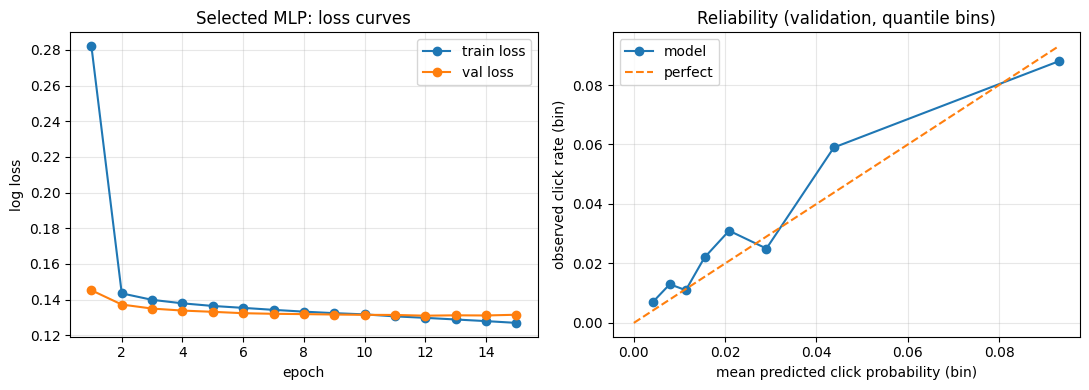

In [26]:
from sklearn.calibration import calibration_curve

cfg_final = configs[chosen]
t0 = time.time()
m_final, hist_f, best_f = run(cfg_final, seed=SEED, verbose=True)
train_s = time.time() - t0
p_va = predict_proba(m_final, *T["va"][:2])
thr_final = best_f1_threshold(y["va"], p_va)
val_m = metrics(y["va"], p_va, thr_final)
n_params = sum(p.numel() for p in m_final.parameters())
print("selected:", chosen, "| best epoch", best_f["ep"], "| params", n_params,
      "| memory (MB, float32 weights)", round(n_params * 4 / 1e6, 2), "| train time (s)", round(train_s))
print("val F1 threshold:", round(thr_final, 3), {k: round(float(v), 4) for k, v in val_m.items()})

frac, mean_p = calibration_curve(y["va"], p_va, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
h = np.array(hist_f)
ax[0].plot(h[:, 0], h[:, 1], marker="o", label="train loss"); ax[0].plot(h[:, 0], h[:, 2], marker="o", label="val loss")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("log loss"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title("Selected MLP: loss curves")
ax[1].plot(mean_p, frac, marker="o", label="model"); ax[1].plot([0, max(mean_p.max(), frac.max())], [0, max(mean_p.max(), frac.max())], "--", label="perfect")
ax[1].set_xlabel("mean predicted click probability (bin)"); ax[1].set_ylabel("observed click rate (bin)")
ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_title("Reliability (validation, quantile bins)")
plt.tight_layout(); plt.savefig("/kaggle/working/results/task02_selected.png", dpi=150, bbox_inches="tight"); plt.show()

## Selected model: F (4-d embeddings, one hidden layer of 32, no dropout)

43,457 parameters (91% in the embeddings), 0.17 MB of float32 weights, 8
seconds to train. Validation: ROC-AUC 0.7204, PR-AUC 0.1014, log loss 0.1315,
F1 0.1616 at threshold 0.10 (precision 0.1495, recall 0.1758, accuracy
0.9416, below the 0.968 of a model that never predicts a click). Validation
loss is lowest at epoch 12 (0.1310) and then drifts up slightly. The
reliability plot (8 quantile bins) follows the diagonal; individual bins
differ by one or two percentage points, which is within what roughly 30
clicks per bin allows.

In [27]:
Xte = (torch.tensor(Xn["te"]), torch.tensor(Xc["te"]))
p_te = predict_proba(m_final, *Xte)
test_m = metrics(y["te"], p_te, thr_final)
print("TEST (one run, val-chosen threshold %.3f):" % thr_final, {k: round(float(v), 4) for k, v in test_m.items()})
print("references: majority-class accuracy", round(1 - y["te"].mean(), 4), "| random-ranker PR-AUC about", round(float(y["te"].mean()), 4))

with open("/kaggle/working/results/task02_results.md", "w") as f:
    f.write("# Task 02 results\n\nSelected: %s | params %d | train time %.0f s | best epoch %d\n\n" % (chosen, n_params, train_s, best_f["ep"]))
    f.write("| split | " + " | ".join(val_m.keys()) + " |\n|---|" + "---|" * len(val_m) + "\n")
    f.write("| val | " + " | ".join("%.4f" % v for v in val_m.values()) + " |\n")
    f.write("| test | " + " | ".join("%.4f" % v for v in test_m.values()) + " |\n")
    f.write("\nThreshold %.3f chosen on val.\n" % thr_final)

TEST (one run, val-chosen threshold 0.100): {'roc_auc': 0.6676, 'pr_auc': 0.0647, 'logloss': 0.1441, 'acc': 0.9415, 'f1': 0.0845, 'precision': 0.0888, 'recall': 0.0806}
references: majority-class accuracy 0.9665 | random-ranker PR-AUC about 0.0335


## Test (one run, threshold 0.10 chosen on validation)

| | Validation | Test |
|---|---|---|
| ROC-AUC | 0.7204 | 0.6676 |
| PR-AUC | 0.1014 | 0.0647 |
| Log loss | 0.1315 | 0.1441 |
| F1 | 0.1616 | 0.0845 |
| Precision / recall | 0.1495 / 0.1758 | 0.0888 / 0.0806 |

Test performance is clearly weaker than validation: PR-AUC is 1.9 times the
test click rate (0.0335), against 3.1 times on validation, and the log loss
beats the constant-rate predictor (about 0.1467) by only 0.0026. [95% bootstrap
intervals: fill in from the next cell.] The causes were not diagnosed;
candidates are selection on validation, differences between `test.csv` and
`train.csv`, and sampling noise with 335 test clicks.

In [28]:


def boot(yt, p, n=1000, seed=0):
    rng = np.random.default_rng(seed); idx = np.arange(len(yt)); out = []
    for _ in range(n):
        s = rng.choice(idx, len(idx), replace=True)
        if yt[s].sum() == 0: continue
        out.append((roc_auc_score(yt[s], p[s]), average_precision_score(yt[s], p[s]), log_loss(yt[s], clipp(p[s]), labels=[0, 1])))
    a = np.array(out)
    return np.percentile(a, 2.5, axis=0), np.percentile(a, 97.5, axis=0)

for name, yt, p in [("val", y["va"], p_va), ("test", y["te"], p_te)]:
    lo, hi = boot(yt, p)
    print(name, "| ROC-AUC %.3f [%.3f, %.3f] | PR-AUC %.4f [%.4f, %.4f] | log loss %.4f [%.4f, %.4f]" % (
        roc_auc_score(yt, p), lo[0], hi[0], average_precision_score(yt, p), lo[1], hi[1],
        log_loss(yt, clipp(p)), lo[2], hi[2]))

val | ROC-AUC 0.720 [0.688, 0.752] | PR-AUC 0.1014 [0.0790, 0.1396] | log loss 0.1315 [0.1188, 0.1442]
test | ROC-AUC 0.668 [0.635, 0.694] | PR-AUC 0.0647 [0.0540, 0.0814] | log loss 0.1441 [0.1310, 0.1575]


## Uncertainty: bootstrap intervals

95% bootstrap intervals (1,000 resamples of the stored predictions; they
capture noise from the number of clicks, not training randomness or selection
on validation):

| | ROC-AUC | PR-AUC | Log loss |
|---|---|---|---|
| Validation | 0.720 [0.688, 0.752] | 0.1014 [0.0790, 0.1396] | 0.1315 [0.1188, 0.1442] |
| Test | 0.668 [0.635, 0.694] | 0.0647 [0.0540, 0.0814] | 0.1441 [0.1310, 0.1575] |

The intervals are wide (256 validation clicks, 335 test clicks) and the
validation and test intervals just touch: ROC-AUC overlaps by 0.006 and
PR-AUC by 0.0024. Each split's point estimate lies outside the other's
interval, so sampling noise alone is a stretch as the explanation for the
drop.

In [29]:
ent = lambda r: -(r * np.log(r) + (1 - r) * np.log(1 - r))
print("mean predicted probability  val %.4f | test %.4f" % (p_va.mean(), p_te.mean()))
print("observed click rate         val %.4f | test %.4f" % (y["va"].mean(), y["te"].mean()))
print("constant-rate log loss      val %.4f | test %.4f" % (ent(y["va"].mean()), ent(y["te"].mean())))
d = (train_full[NUM + CAT].isna().mean() - test[NUM + CAT].isna().mean()).abs().sort_values(ascending=False)
print("largest missing-rate gap, train vs test:", d.head(3).round(3).to_dict())
print("categorical cells at the unknown index: val %.3f | test %.3f" % ((Xc["va"] == 0).mean(), (Xc["te"] == 0).mean()))
print("predicted-positive share at the threshold: val %.4f | test %.4f" % ((p_va >= thr_final).mean(), (p_te >= thr_final).mean()))

mean predicted probability  val 0.0282 | test 0.0269
observed click rate         val 0.0320 | test 0.0335
constant-rate log loss      val 0.1416 | test 0.1467
largest missing-rate gap, train vs test: {'integer_feature_6': 0.026, 'integer_feature_10': 0.026, 'integer_feature_5': 0.023}
categorical cells at the unknown index: val 0.141 | test 0.157
predicted-positive share at the threshold: val 0.0376 | test 0.0304


## Calibration and distribution check

| | Validation | Test |
|---|---|---|
| Mean predicted probability | 0.0282 | 0.0269 |
| Observed click rate | 0.0320 | 0.0335 |
| Constant-rate log loss | 0.1416 | 0.1467 |
| Unknown-index categorical cells | 14.1% | 15.7% |
| Flagged at threshold 0.10 | 3.76% | 3.04% |

The model under-predicts mildly on both splits (88% of the observed rate on
validation, 80% on test), possibly because the selected configuration was still
improving at the 15-epoch cap (untested). Since ROC-AUC also fell on test
(0.720 to 0.668) and AUC ignores scale, the weaker test result reflects worse
ranking, not only the probability scale. The largest missing-rate gaps
between `train.csv` and `test.csv` are 2.6 percentage points
(`integer_feature_6` and `_10`), about 8 standard errors by my rough estimate
(about 0.3 points), so `test.csv` probably is not a random sample from the
same pool as `train.csv`. I did not show that this explains the drop.

In [30]:
print("split fingerprint | train clicks", int(y["tr"].sum()), "| val clicks", int(y["va"].sum()),
      "| dense sum", round(float(Xn["tr"].sum()), 1), "| cat index sum", int(Xc["tr"].sum()),
      "| val cat index sum", int(Xc["va"].sum()))

split fingerprint | train clicks 1024 | val clicks 256 | dense sum -0.0 | cat index sum 38103084 | val cat index sum 9050373


## Split fingerprint (Task 03 must reproduce it)

train clicks 1,024 | val clicks 256 | categorical index sum 38,103,084 (train)
and 9,050,373 (validation). The dense sum is zero by construction (standardised
features), so it does not distinguish splits.

In [31]:
import sys, sklearn, matplotlib
print("python", sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__,
      "| torch", torch.__version__, "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
print("device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "cpu")
print("seeds: split", SEED, "| sweep seeds 42, 43, 44 | selected-model seed", SEED)

python 3.13.15 | numpy 2.1.3 | pandas 2.2.3 | torch 2.11.0+cpu | scikit-learn 1.6.1 | matplotlib 3.10.0
device: cpu | cpu
seeds: split 42 | sweep seeds 42, 43, 44 | selected-model seed 42


In [32]:
lo_v, hi_v = boot(y["va"], p_va); lo_t, hi_t = boot(y["te"], p_te)
L = ["# Task 02 results", "",
     "Selected: %s | params %d | weight memory %.2f MB | train time %.0f s | best epoch %d | threshold %.3f" % (
         chosen, n_params, n_params * 4 / 1e6, train_s, best_f["ep"], thr_final), "",
     "## Architecture sweep (mean over seeds 42, 43, 44; validation)", "",
     "| config | params | best epoch | PR-AUC | PR std | AUC | AUC std | log loss |", "|---|---|---|---|---|---|---|---|"]
for _, r in sw.iterrows():
    L.append("| %s | %d | %.1f | %.4f | %.4f | %.4f | %.4f | %.4f |" % (
        r["config"], r["params"], r["best epoch"], r["PR-AUC"], r["PR std"], r["AUC"], r["AUC std"], r["logloss"]))
L += ["", "## Selected model, val and test (test: one run)", "",
      "| split | ROC-AUC (95% CI) | PR-AUC (95% CI) | log loss (95% CI) | acc | F1 | precision | recall |",
      "|---|---|---|---|---|---|---|---|"]
for name, m_, lo, hi in [("val", val_m, lo_v, hi_v), ("test", test_m, lo_t, hi_t)]:
    L.append("| %s | %.3f [%.3f, %.3f] | %.4f [%.4f, %.4f] | %.4f [%.4f, %.4f] | %.4f | %.4f | %.4f | %.4f |" % (
        name, m_["roc_auc"], lo[0], hi[0], m_["pr_auc"], lo[1], hi[1], m_["logloss"], lo[2], hi[2],
        m_["acc"], m_["f1"], m_["precision"], m_["recall"]))
open("/kaggle/working/results/task02_results.md", "w").write("\n".join(L))
print("\n".join(L[-5:]))


| split | ROC-AUC (95% CI) | PR-AUC (95% CI) | log loss (95% CI) | acc | F1 | precision | recall |
|---|---|---|---|---|---|---|---|
| val | 0.720 [0.688, 0.752] | 0.1014 [0.0790, 0.1396] | 0.1315 [0.1188, 0.1442] | 0.9416 | 0.1616 | 0.1495 | 0.1758 |
| test | 0.668 [0.635, 0.694] | 0.0647 [0.0540, 0.0814] | 0.1441 [0.1310, 0.1575] | 0.9415 | 0.0845 | 0.0888 | 0.0806 |


In [33]:
import shutil
shutil.make_archive("/content/task02_results", "zip", "/kaggle/working/results")
from google.colab import files
files.download("/content/task02_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>